In [1]:
import torch

import numpy as np
import torch.nn as nn

from architecture.pignn.pignn import FlowPIGNN
from utils.visualization import plot_prediction_vs_real
from architecture.pignn.deconv import FCDeConvNet
from experiments.graphs.graph_experiments import create_data_loaders, get_config, custom_collate_fn, GraphTemporalDataset, GraphDataset

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
# Load the data from a past experiment
case_nr = 1
max_angle = 30
seq_length = 50
wake_steering = False
use_graph = True
type = "LuT2deg_internal" if wake_steering else "BL"
batch_size = 4
data_folder = f"../../data/Case_0{case_nr}/graphs/{type}/{max_angle}"
dataset = GraphTemporalDataset(root=data_folder, seq_length=seq_length) if seq_length > 1 else GraphDataset(root=data_folder)
collate = custom_collate_fn if seq_length > 1 else None
config = get_config(case_nr=case_nr, wake_steering=wake_steering, max_angle=max_angle, use_graph=use_graph)
train_loader, val_loader, test_loader = create_data_loaders(dataset, config.train.batch_size, custom_collate=collate)

In [4]:
print(len(train_loader))

403


In [21]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 906865 parameters without deconv
# 915874 parameters with deconv, conv gives only 1 percent of the params
# 907006 for FCN

In [15]:
# Calculate convolution output sizes
dim_x = 10
dim_y = 50

k = [4, 4, 4]
s = [2, 2, 2]
p = [1, 1, 1]

for i in range(len(k)):
    dim_x = s[i] * (dim_x - 1) + k[i] - 2 * p[i]
    dim_y = s[i] * (dim_y - 1) + k[i] - 2 * p[i]

print(dim_x * dim_y)

32000


In [4]:
# Plot results for fully connected embedder
model = FCDeConvNet(232, 650, 656, 500).to(device)
model.load_state_dict(torch.load("../../results/20240924005510_Case01_False_fcn_deconv/pignn_161.pt"))
model.eval()
criterion = nn.MSELoss()

with torch.no_grad():
    test_losses = []
    for i, batch in enumerate(test_loader):
        x = batch.x.to(device)
        pos = batch.pos.to(device)
        edge_attr = batch.edge_attr.to(device)
        glob = batch.global_feats.to(device)
        batch_size = glob.size(0)

        x_cat = torch.cat((
            x.reshape(batch_size, -1),
            pos.reshape(batch_size, -1),
            edge_attr.reshape(batch_size, -1),
            glob.reshape(batch_size, -1)
        ), dim=-1).float()

        pred = model(x_cat)
        target = batch.y.to(device).reshape(-1, pred.size(1))
        test_loss = criterion(pred, target)
        plot_prediction_vs_real(pred[0, :].reshape(300, 300).cpu(), target[0, :].reshape(300, 300).cpu())
        test_losses.append(test_loss.item())

    print(f"test loss: {np.mean(test_losses)}")

C:\Users\Matth\AppData\Local\Temp\ipykernel_14292\2534070951.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../../results/202409240055

FileNotFoundError: [Errno 2] No such file or directory: '../../results/20240924005510_Case01_False_fcn_deconv/pignn_161.pt'

C:\Users\Matth\AppData\Local\Temp\ipykernel_19632\890895271.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("results/20240930155721_Case

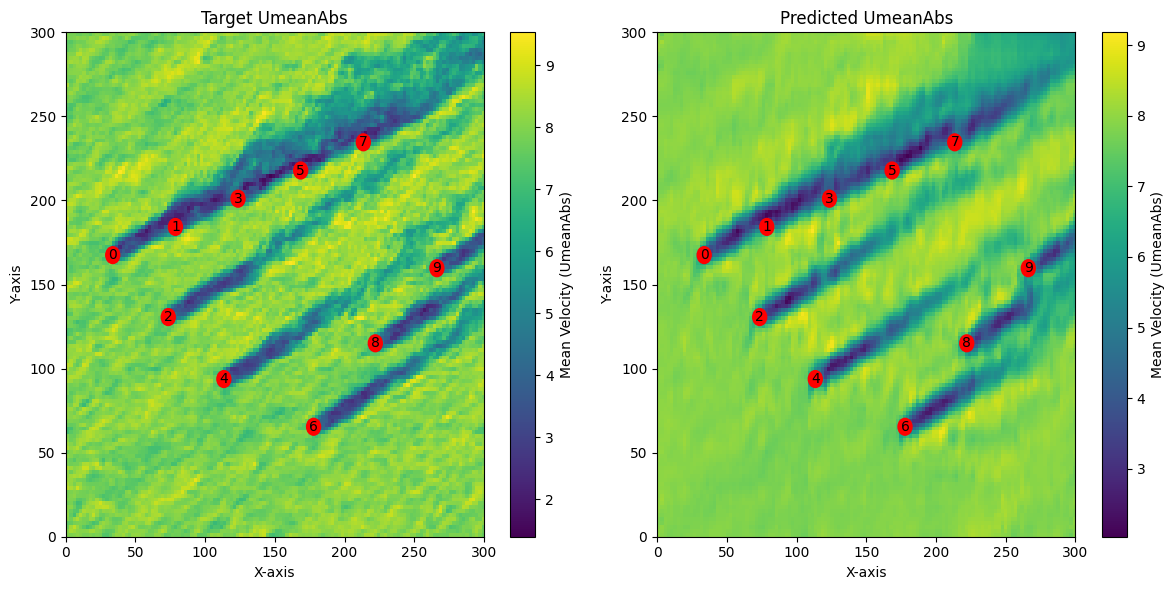

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


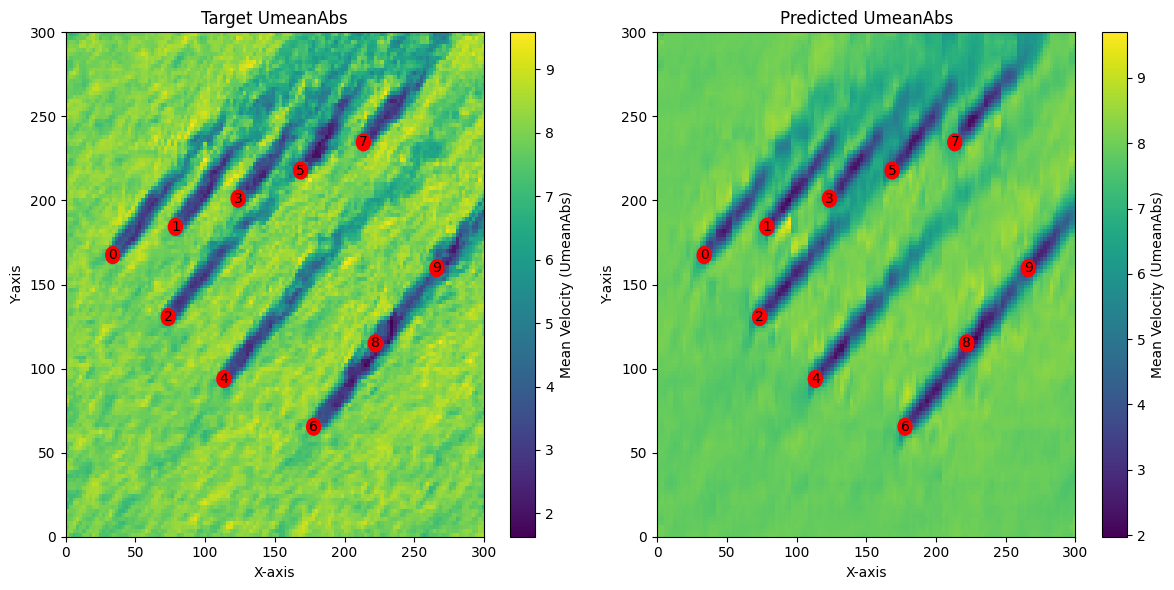

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


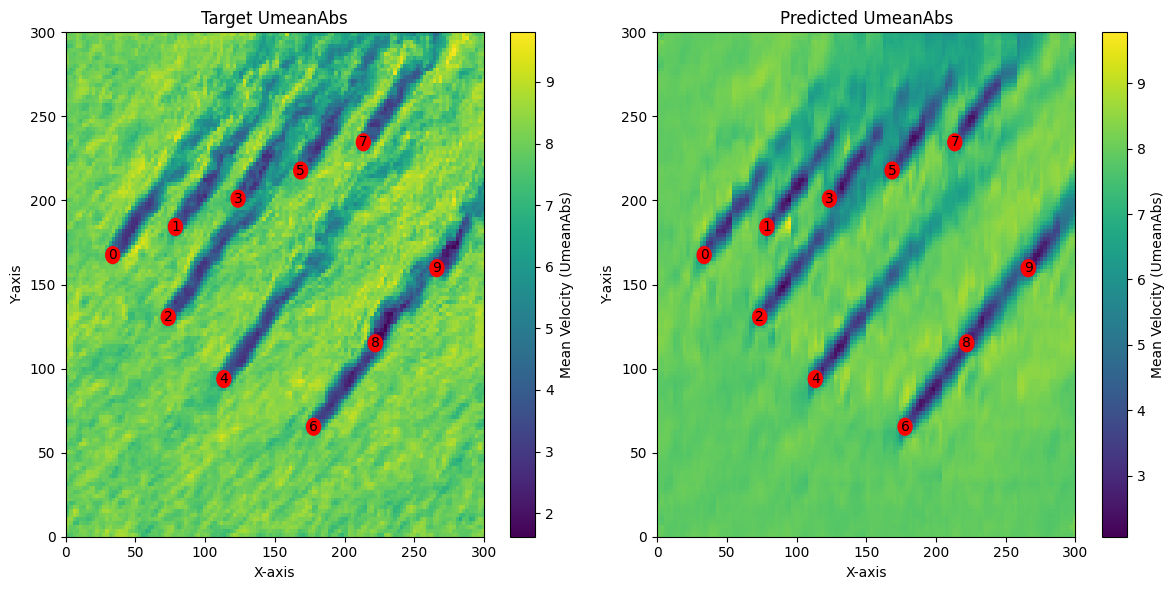

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


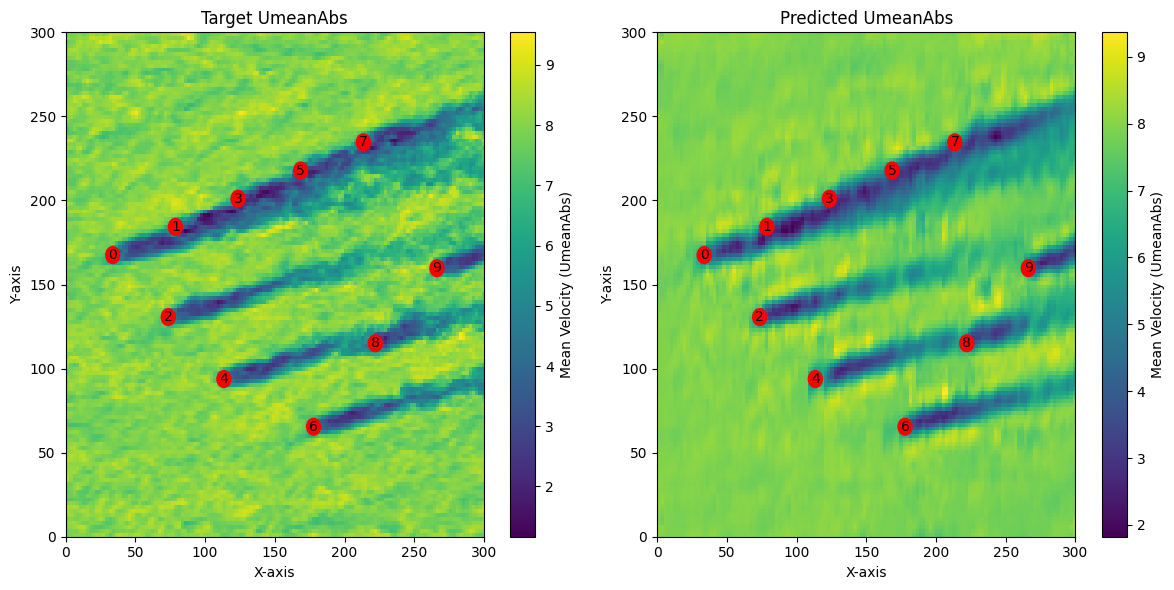

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


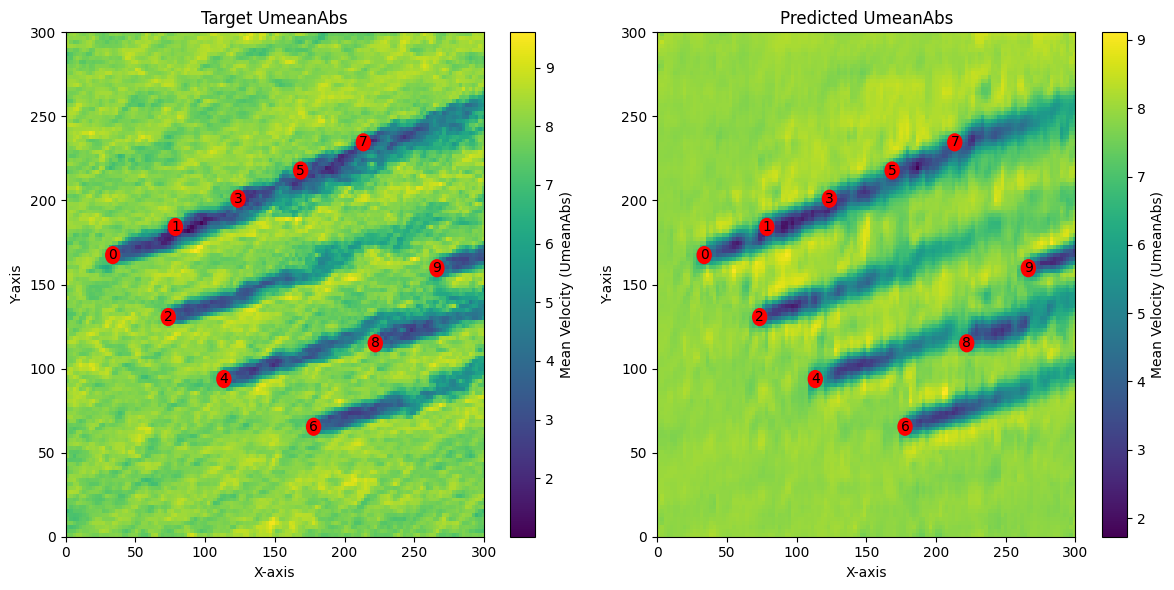

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


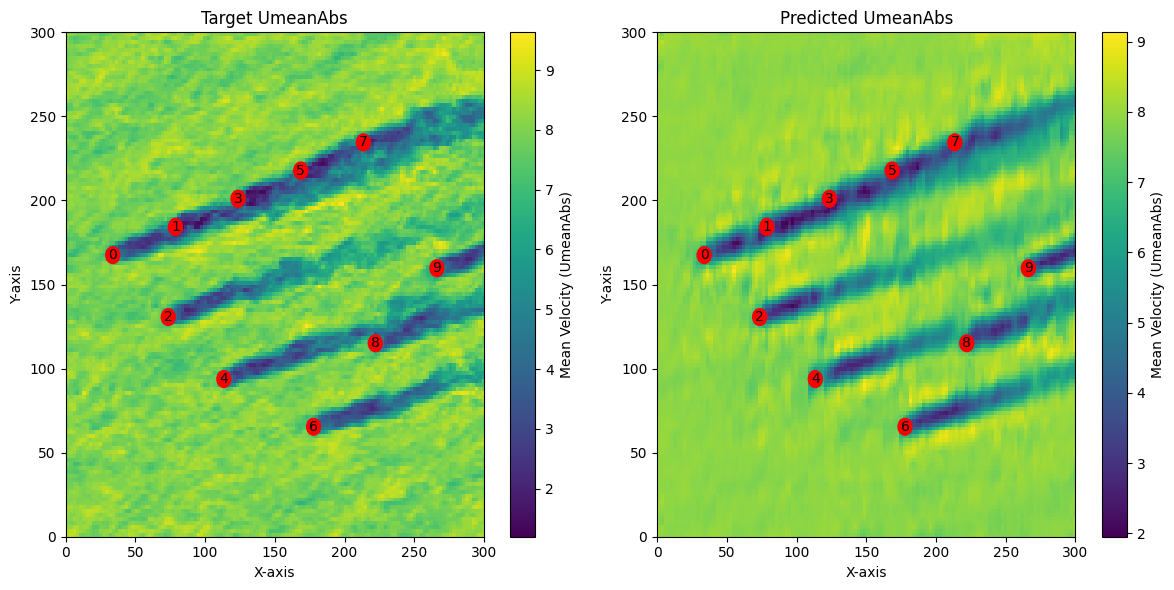

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


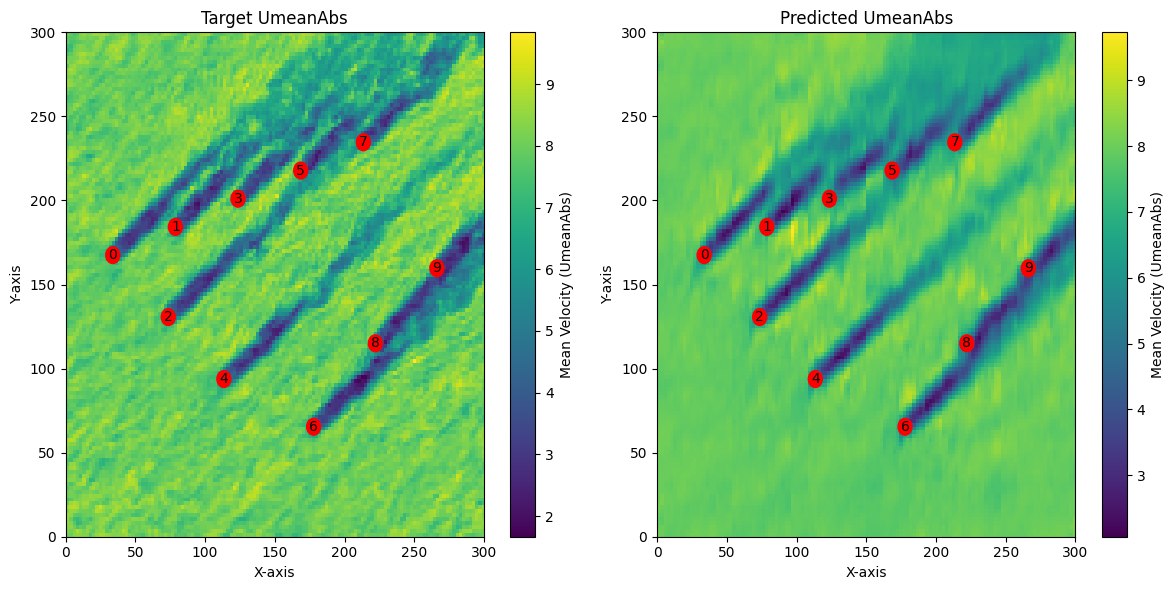

D:\AI2P\repo\experiments\graphs\graph_experiments.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_data = torch.load(graph_path)


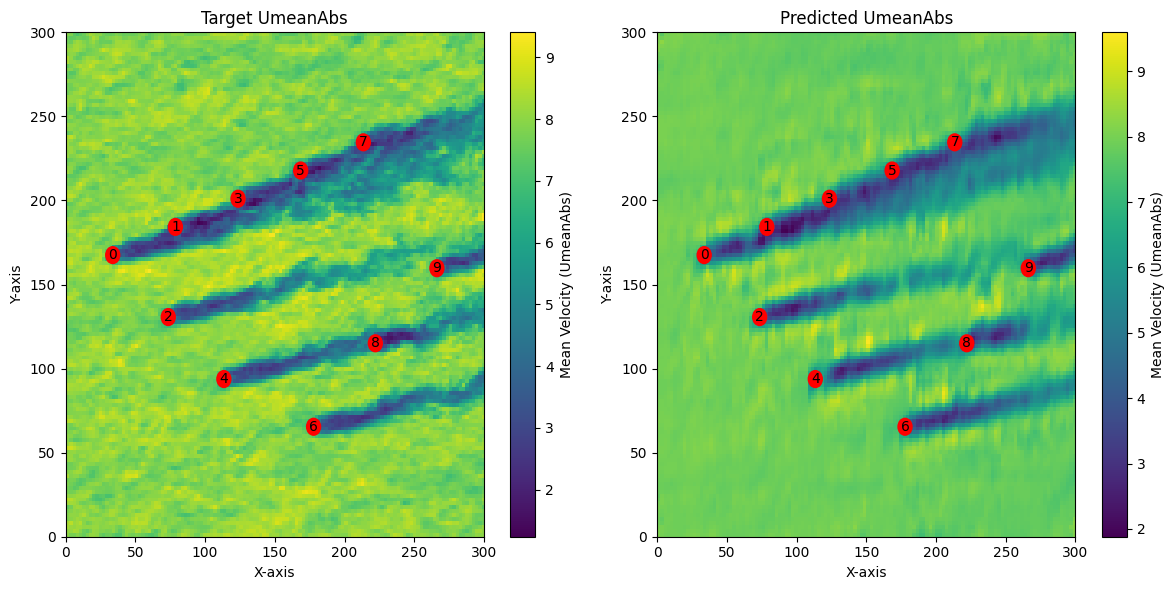

test loss: 0.33705319836735725


In [4]:
# Plot results for PIGNN embedder
model = FlowPIGNN(**config.model).to(device)
model.load_state_dict(torch.load("results/20240930155721_Case01_False_pignn_deconv_30/pignn_101.pt"))
model.eval()
image_size = 128
criterion = nn.MSELoss()

with torch.no_grad():
    test_losses = []
    for i, batch in enumerate(test_loader):
        batch = batch.to(device)
        nf = torch.cat((batch.x.to(device), batch.pos.to(device)), dim=-1).float()
        ef = batch.edge_attr.to(device).float()
        gf = batch.global_feats.to(device).float()
        pred = model(batch, nf, ef, gf)
        target = batch.y.to(device).reshape(-1, pred.size(1))
        test_loss = criterion(pred, target)
        plot_prediction_vs_real(pred[0, :].reshape(image_size, image_size).cpu(), target[0, :].reshape(image_size, image_size).cpu())
        test_losses.append(test_loss.item())

    print(f"test loss: {np.mean(test_losses)}")

C:\Users\Matth\AppData\Local\Temp\ipykernel_29840\3624305454.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph_model.load_state_dict(torch.load("results/202410011015

50 128


C:\Users\Matth\AppData\Local\Temp\ipykernel_29840\3624305454.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  temporal_model.load_state_dict(torch.load("results/202410011

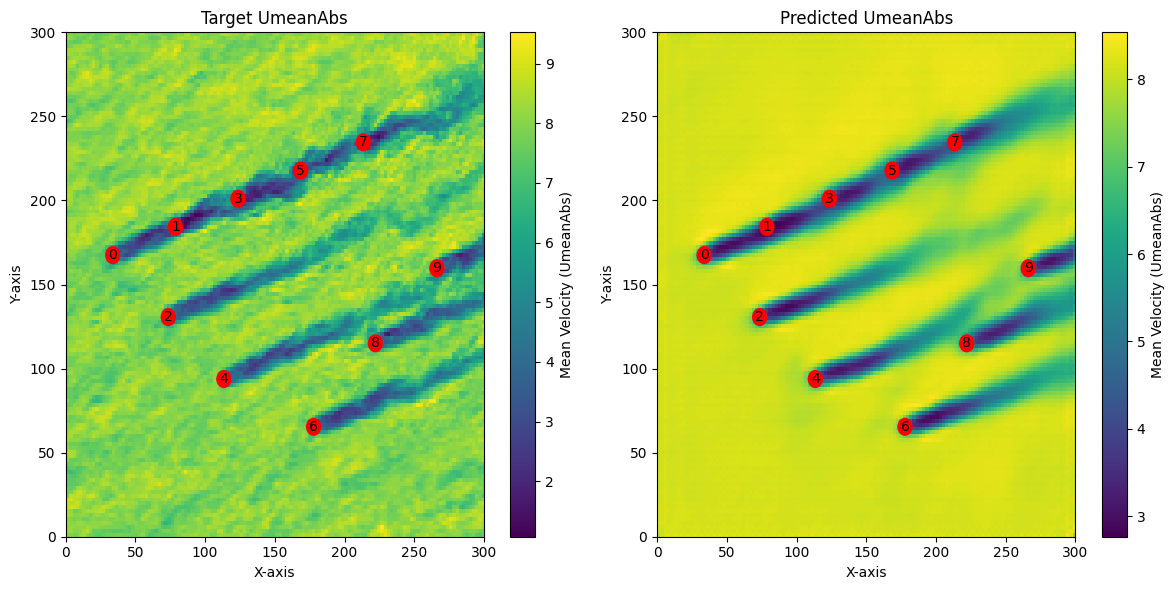

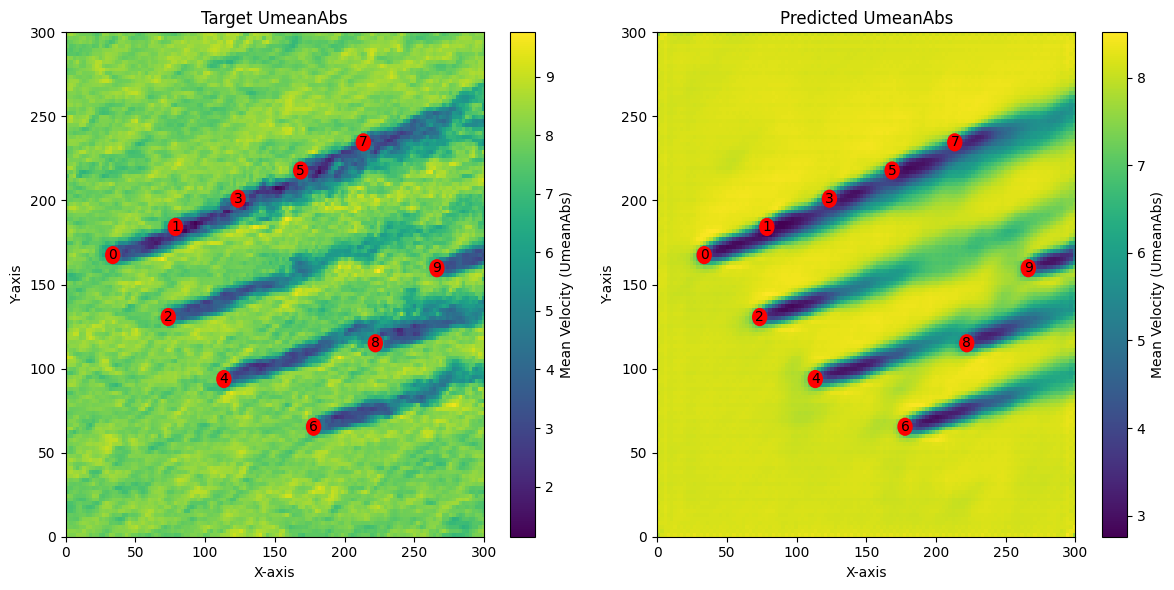

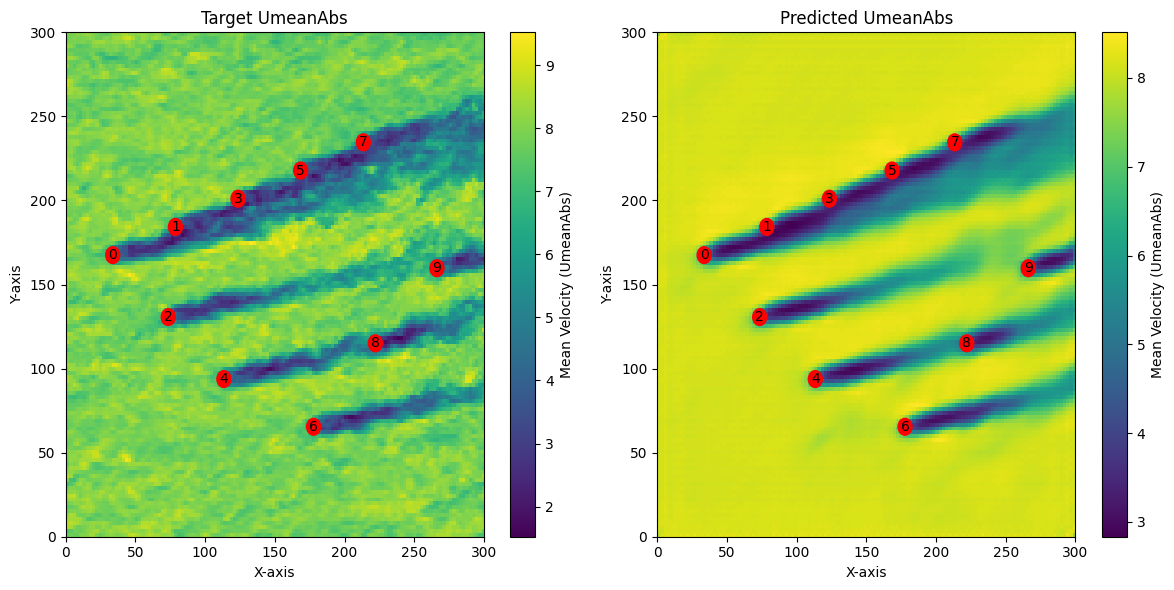

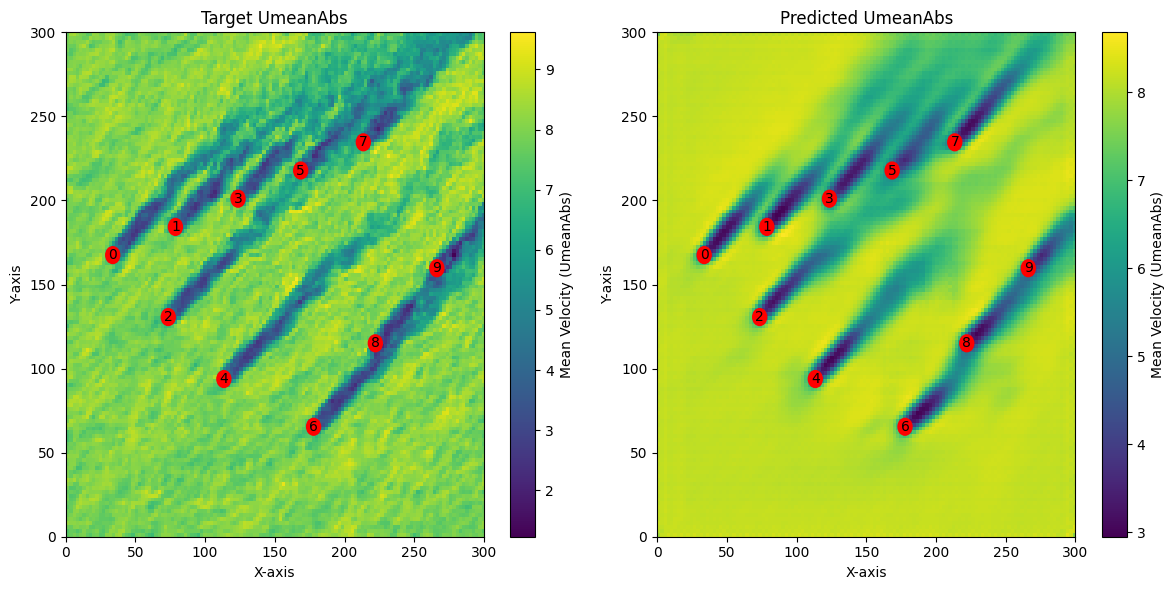

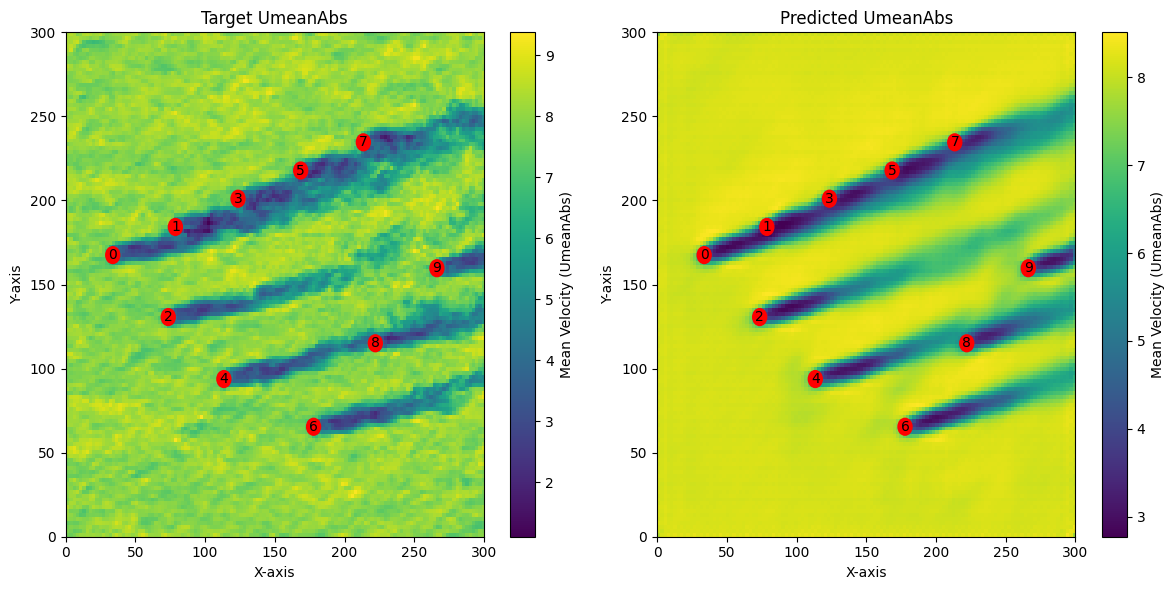

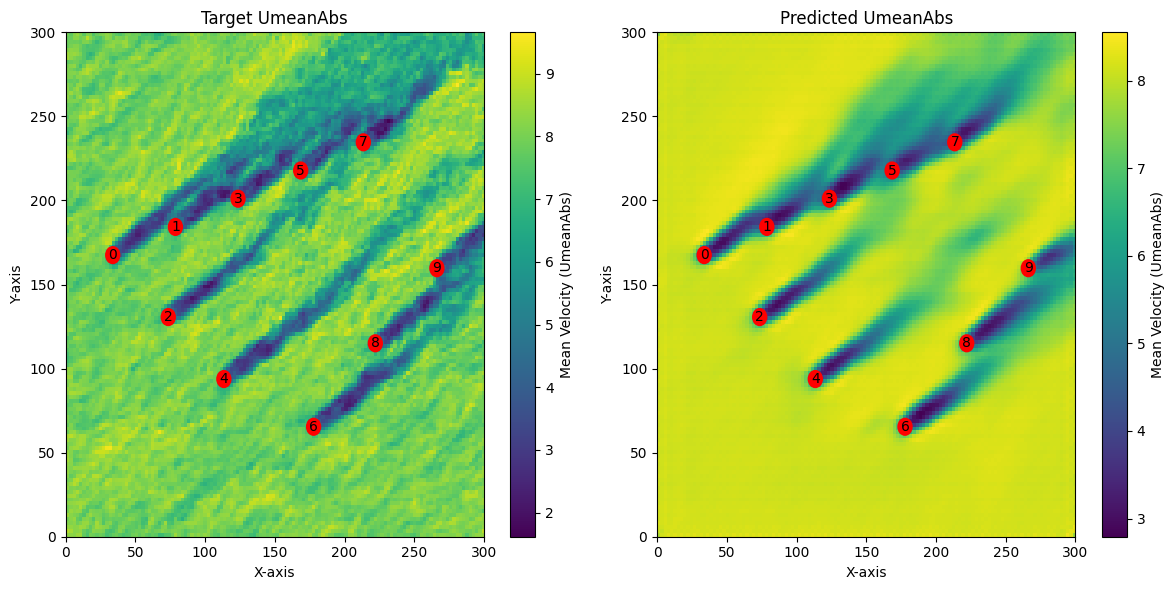

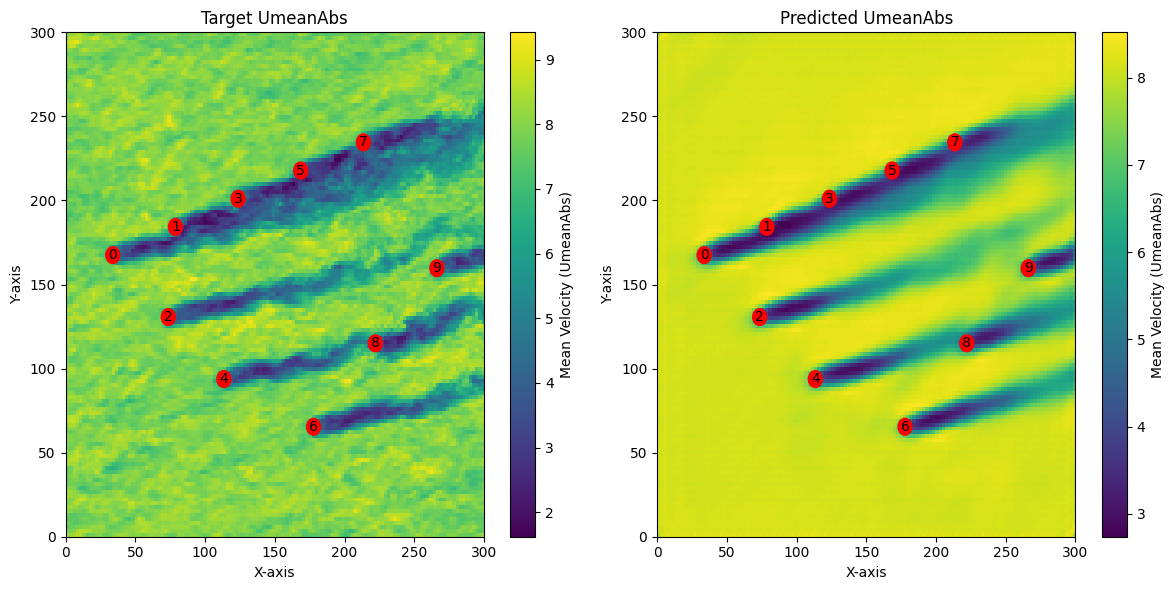

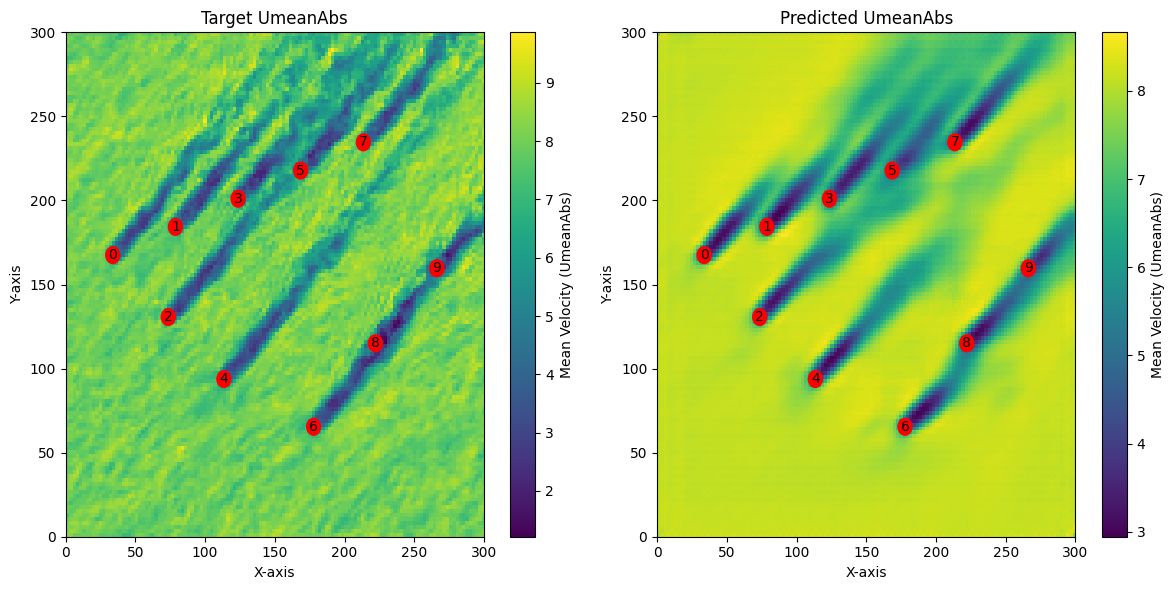

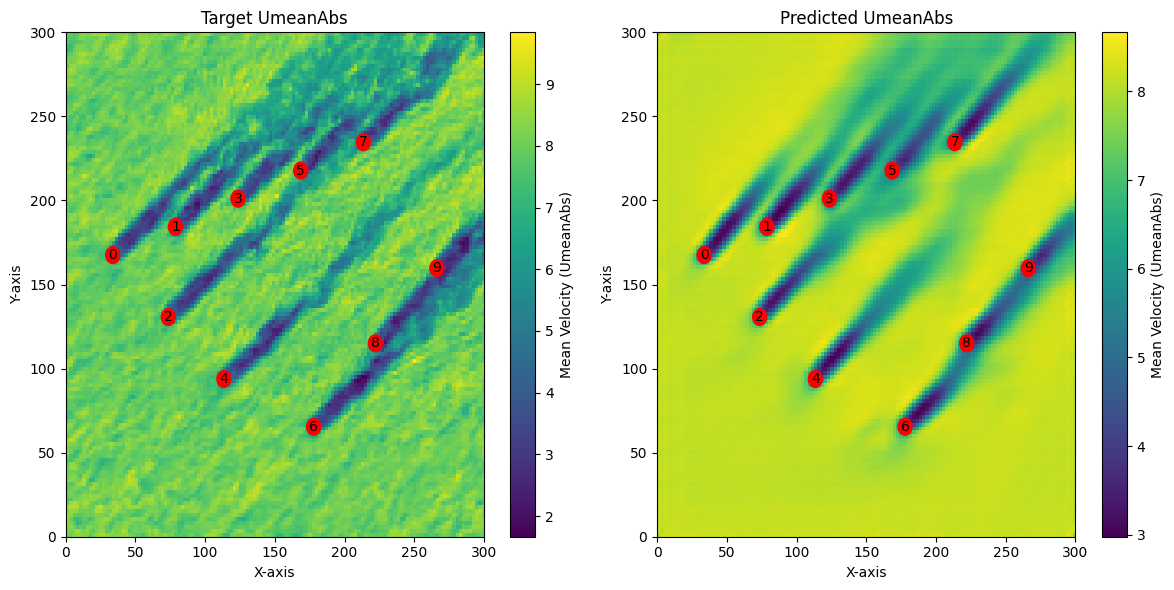

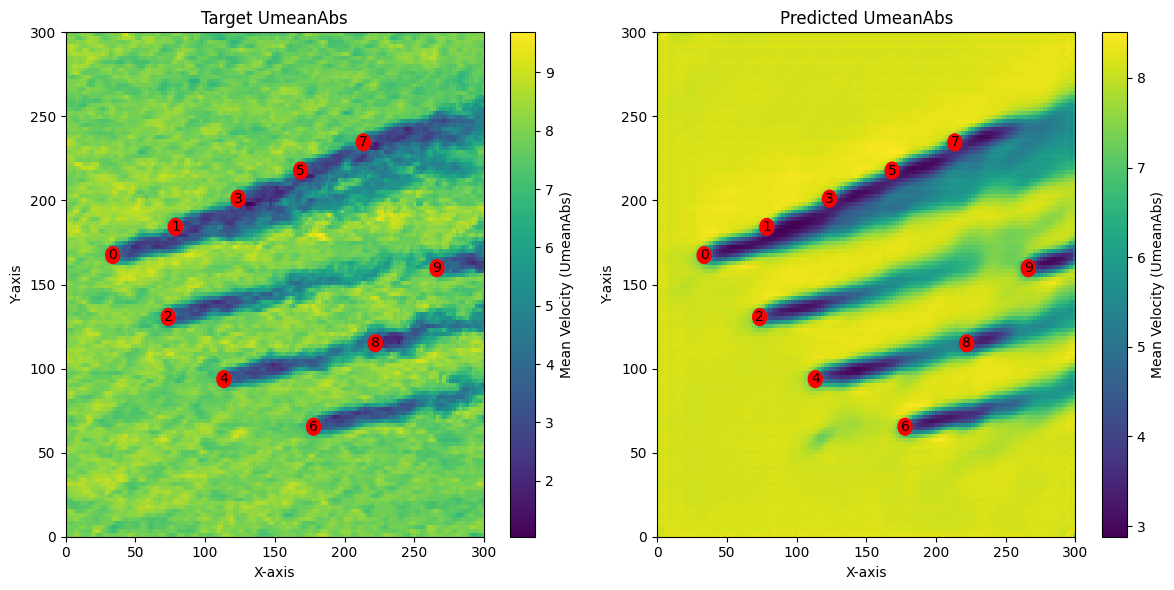

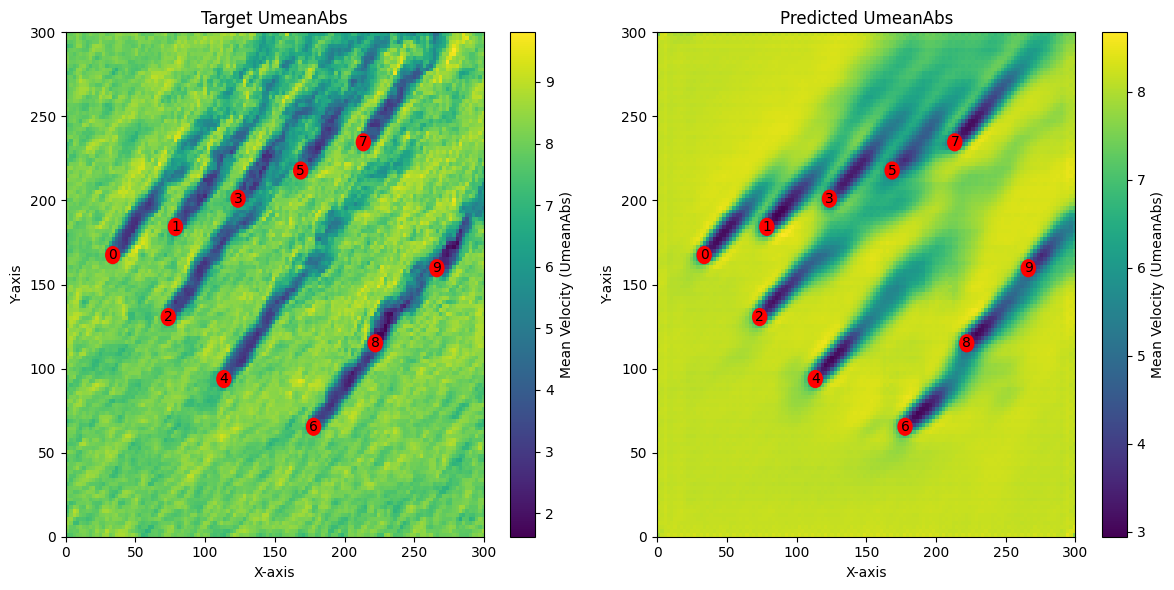

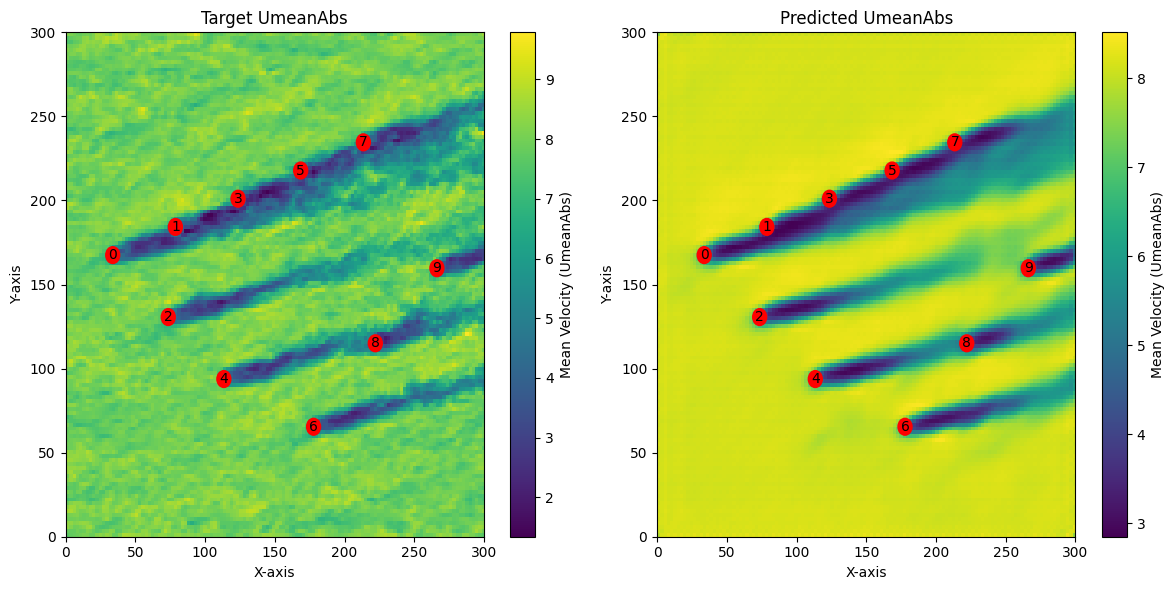

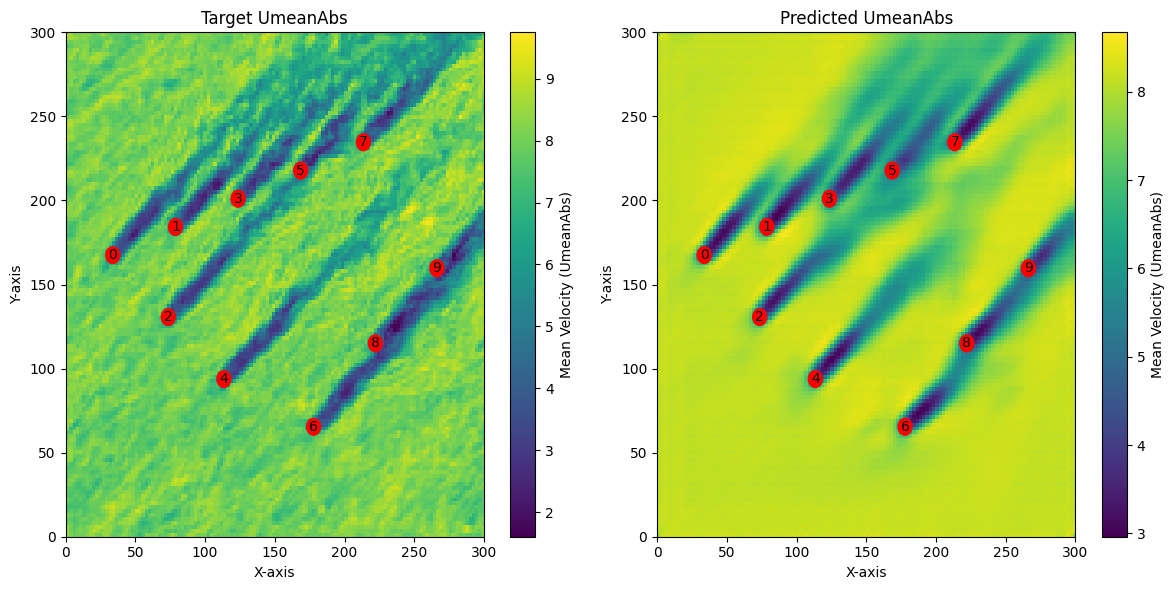

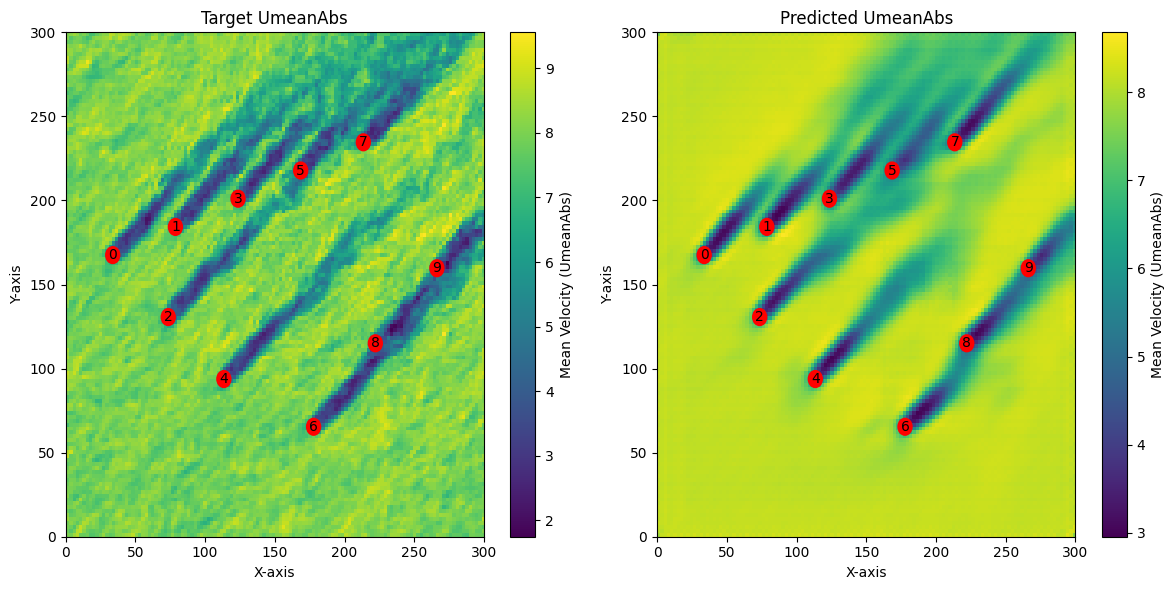

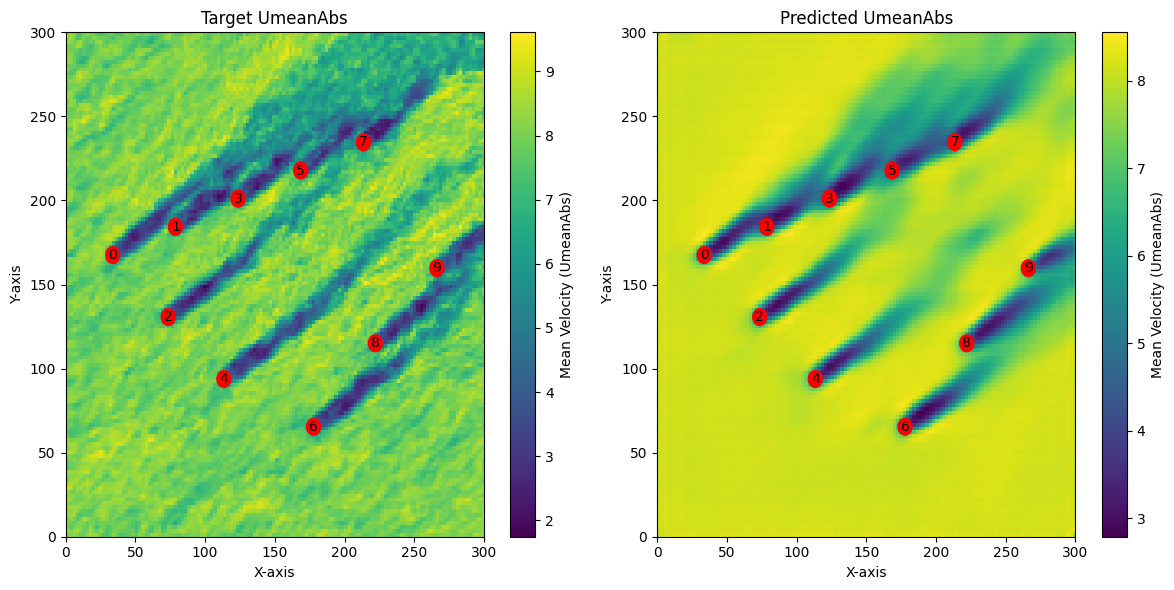

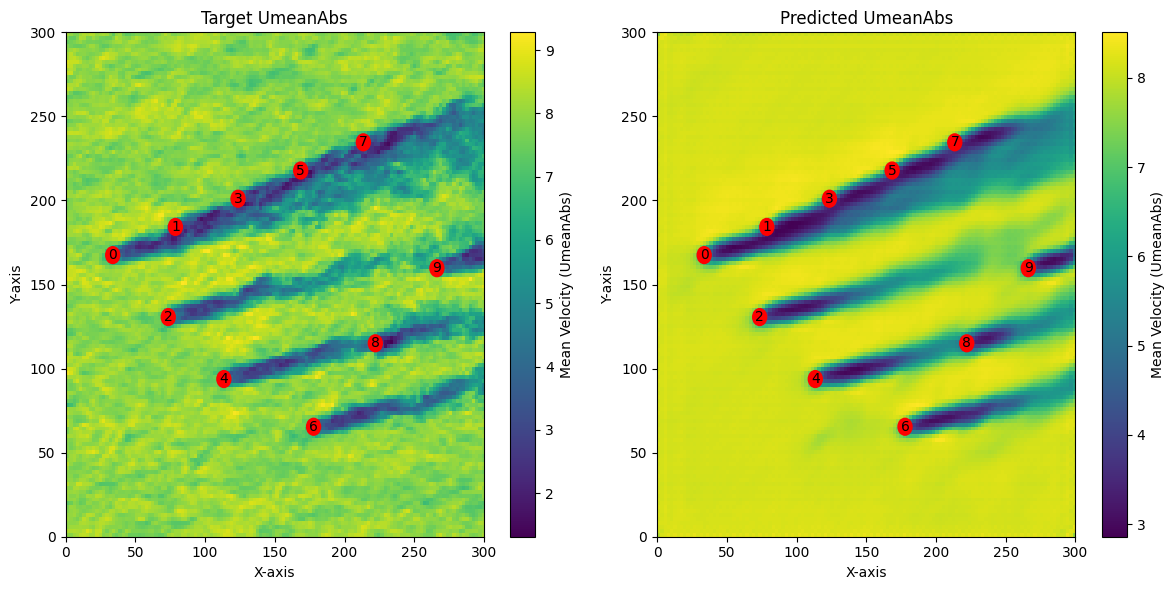

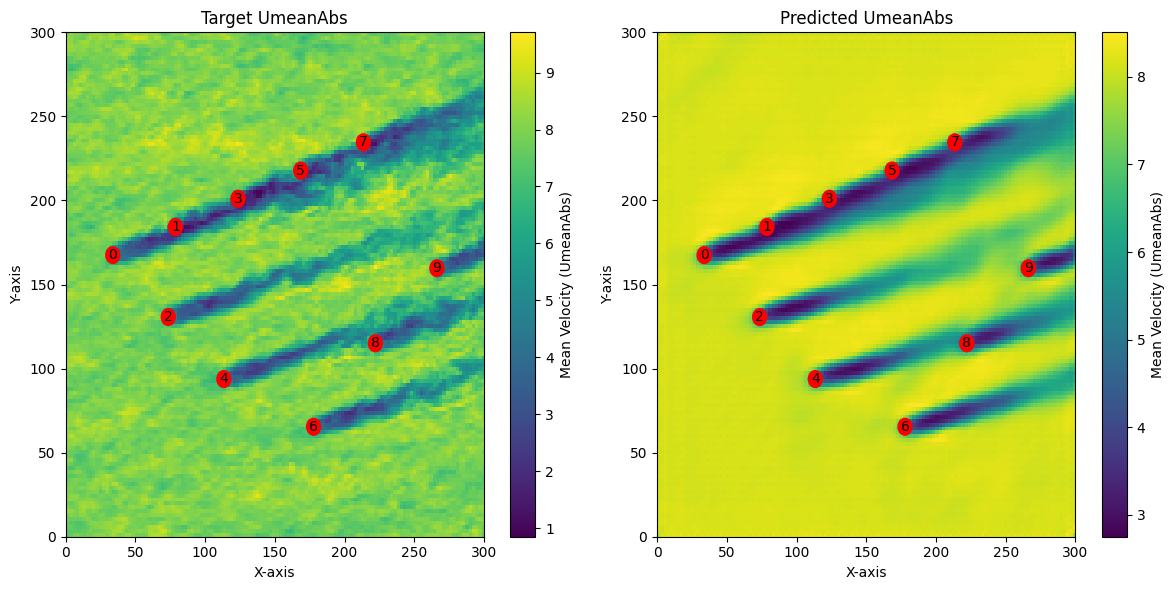

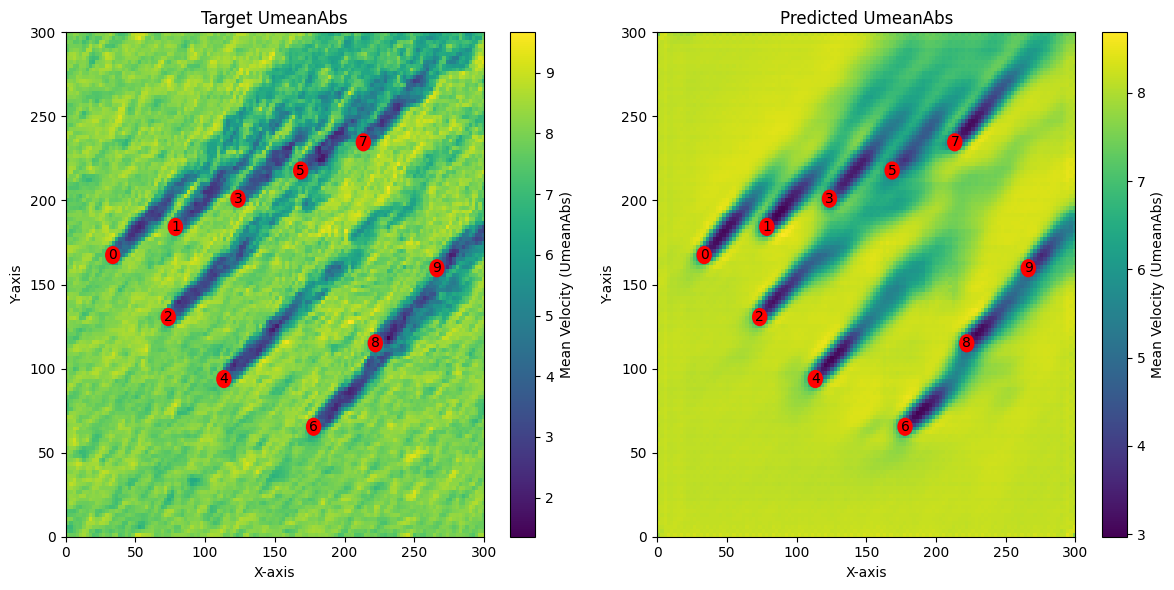

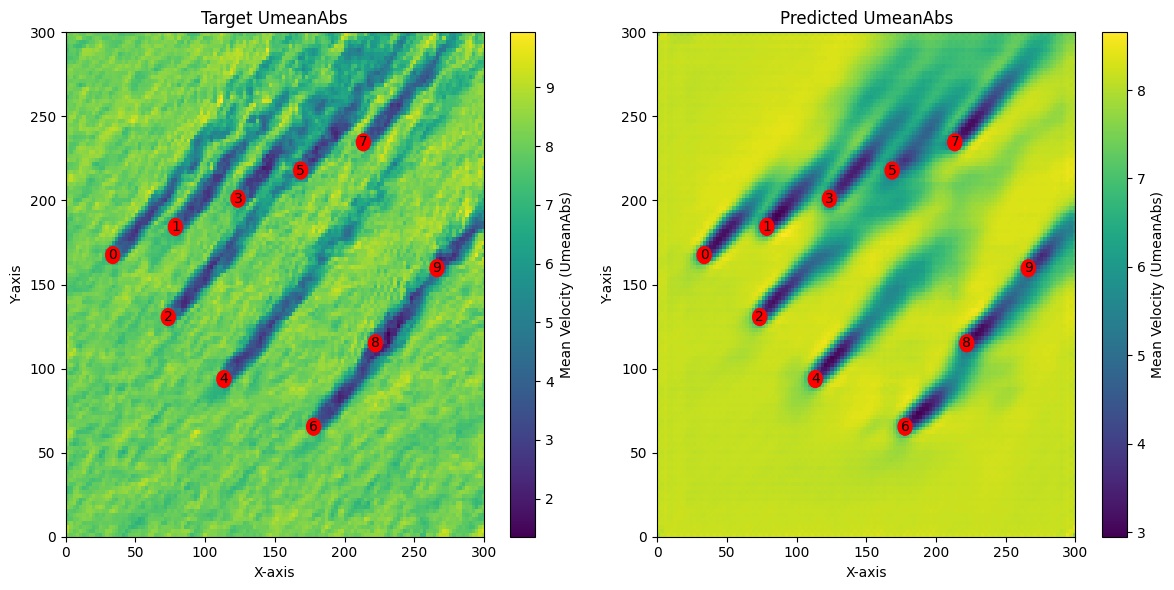

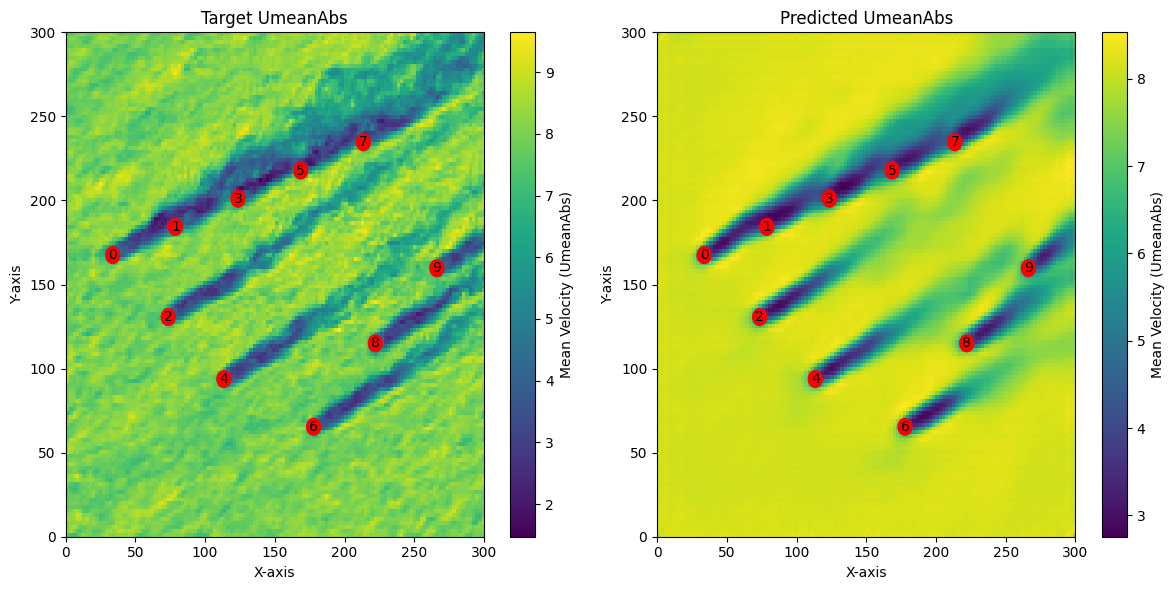

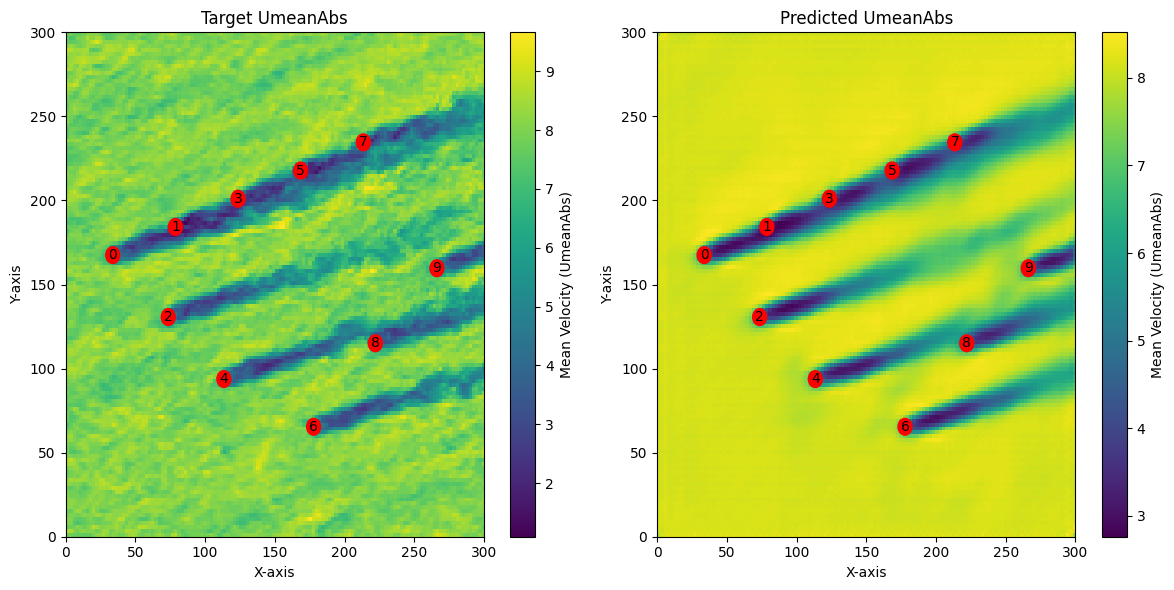

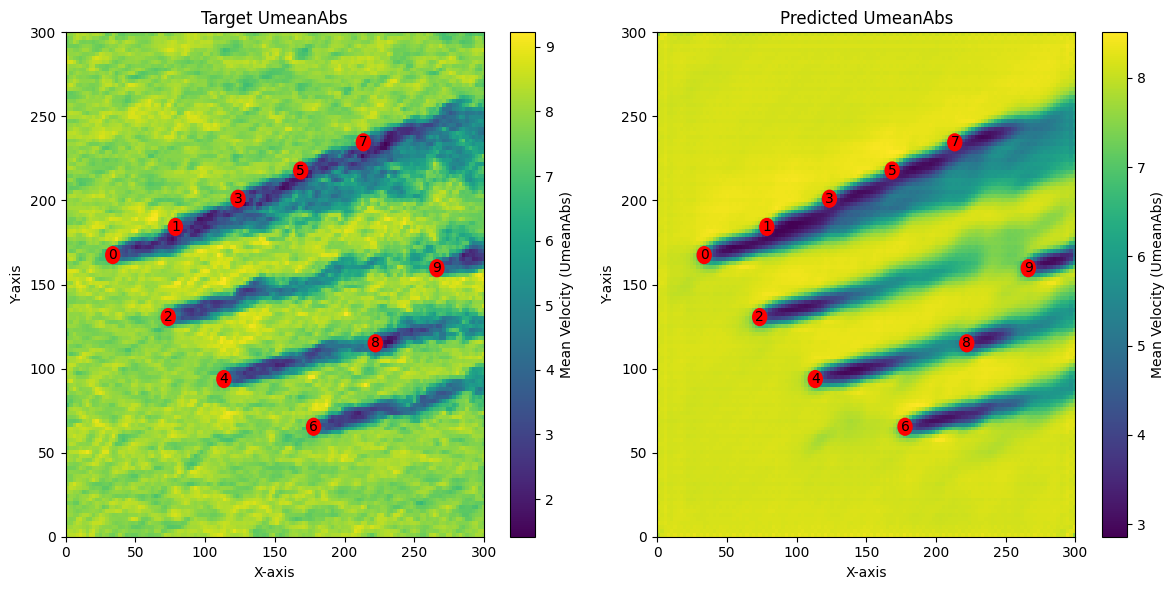

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000016D6673F4C0>
Traceback (most recent call last):
  File "D:\AI2P\repo\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "D:\AI2P\repo\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1465, in _shutdown_workers
    w.terminate()
  File "C:\Users\Matth\AppData\Local\Programs\Python\Python311\Lib\multiprocessing\process.py", line 133, in terminate
    self._popen.terminate()
  File "C:\Users\Matth\AppData\Local\Programs\Python\Python311\Lib\multiprocessing\popen_spawn_win32.py", line 124, in terminate
    _winapi.TerminateProcess(int(self._handle), TERMINATE)
PermissionError: [WinError 5] Toegang geweigerd


KeyboardInterrupt: 

In [8]:
from architecture.windspeedLSTM.windspeedLSTM import WindspeedLSTM

# Plot the result for temporal network
graph_model = FlowPIGNN(**config.model).to(device)
graph_model.load_state_dict(torch.load("results/20241001101526_Case01_False_pignn_deconv_30_50/pignn_3.pt"))

temporal_model = WindspeedLSTM(seq_length, 128).to(device)
temporal_model.load_state_dict(torch.load("results/20241001101526_Case01_False_pignn_deconv_30_50/unet_lstm_3.pt"))

graph_model.eval()
temporal_model.eval()
image_size = 128
criterion = nn.MSELoss()

with torch.no_grad():
    test_losses = []
    for i, batch in enumerate(test_loader):
        generated_img = []
        target_img = []
        for i, seq in enumerate(batch[0]):
            # Process graphs in parallel at each timestep for the entire batch
            seq = seq.to(device)
            nf = torch.cat((seq.x.to(device), seq.pos.to(device)), dim=-1)
            ef = seq.edge_attr.to(device)
            gf = seq.global_feats.to(device)
            graph_output = graph_model(seq, nf, ef, gf).reshape(-1, image_size, image_size)
            generated_img.append(graph_output)
            target_img.append(batch[1][i].y.to(device).reshape(-1, image_size, image_size))

        temporal_img = torch.stack(generated_img, dim=1)
        output = temporal_model(temporal_img).float()
        target = torch.stack(target_img, dim=1)
        test_loss = criterion(output, target)
        plot_prediction_vs_real(output[0, seq_length - 1].cpu(), target[0, seq_length - 1].cpu())
        test_losses.append(test_loss.item())

    print(f"test loss: {np.mean(test_losses)}")